# Klein Filters

In the paper [Topological Convolutional Layers for Deep Learning](https://www.jmlr.org/papers/volume24/21-0073/21-0073.pdf#10) Love et al define a function $F_K$ that maps Klein bottle into the space of quadratic functions on $[-1,1]^2$. This map is given by 

$$
\begin{align*}
F_K(\theta_1, \theta_2)(x,y) &= \sin(\theta_2)\left( \cos(\theta_1)x + \sin(\theta_1)y \right)
+ \cos(\theta_2) Q\left( \cos(\theta_1)x + \sin(\theta_1)y \right) = \\
&= \begin{bmatrix} \sin(\theta_2) & \cos(\theta_2) \end{bmatrix} \begin{bmatrix} t \\ Q(t) \end{bmatrix}
\end{align*}
$$

where $t = \cos(\theta_1)x + \sin(\theta_1)y = (x,y)\cdot\left( \cos \theta_1, \sin \theta_1 \right)$ and $Q$ is the degree-2 Chebyshev polynomial defined as 

$$
Q(t) = 2t^2 - 1.
$$

As given, $F_K$ is a function on **2-dimensional torus** $S^1\times S^1$, parametrized by angles $\theta_1$ and $\theta_2$ correspondingly. However it is straightforward to see that $F_K$ satisfies the following properties:
1. $F_K(\theta_1, \theta_2) = F_K(\theta_1 + 2\pi k, \theta_2 + 2\pi l)$,
2. $F_K(\theta_1, \theta_2) = F_K(\theta_1 + \pi, -\theta_2)$.

Therefore it actually defines a function on a **Klein bottle** $K$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from ripser import ripser
from persim import plot_diagrams
from gudhi.dtm_rips_complex import DTMRipsComplex

from collections import defaultdict

import umap


/Users/snopoff/Documents/Research/KleinVAE/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def projection_onto_a_line(theta: float) -> float:
    """
    Creates a function that projects a point onto a line.
    """
    return lambda x,y: (x * np.cos(theta) + y * np.sin(theta))
    

def chebyshev_2(t: float) -> float:
    """
    Chebyshev polynomial of the 2nd degree.
    """
    return 2 * t**2 - 1


def klein_filter(theta_1: float, theta_2: float) -> float:
    """
    Klein filter for given angles theta_1 and theta_2.
    """
    t = projection_onto_a_line(theta_1)
    return lambda x,y: np.sin(theta_2) * t(x,y) + np.cos(theta_2) * chebyshev_2(t(x,y))

In [3]:
def generate_klein_filter_matrix(theta_1, theta_2, size=3):
    """
    Generate a Klein filter matrix of given size for specified angles.
    """
    f = klein_filter(theta_1, theta_2)
    x = np.linspace(-1, 1, size)
    y = np.linspace(-1, 1, size)
    X, Y = np.meshgrid(x, y)
    Z = f(X, Y)
    return Z

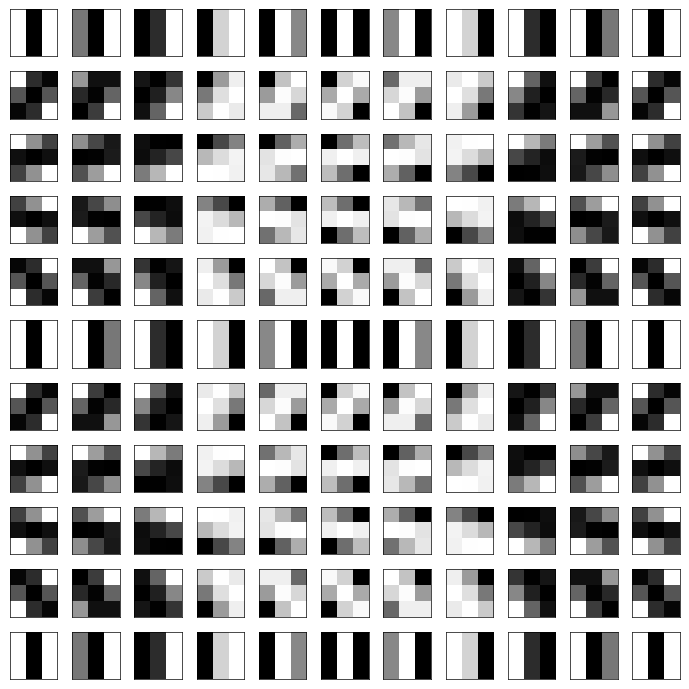

In [4]:
n = 10

fig, axes = plt.subplots(n+1, n+1, figsize=(7, 7))
for i in range(0, n+1):
    for j in range(0, n+1):
        theta_1 = 2 * np.pi * i / n
        theta_2 = 2 * np.pi * j / n
        filter_img = generate_klein_filter_matrix(theta_1, theta_2, size=3)
        axes[i, j].imshow(filter_img, cmap='gray', extent=[-1, 1, -1, 1])
        # Draw black border
        for spine in axes[i, j].spines.values():
            spine.set_edgecolor('black')
            spine.set_linewidth(0.5)
        axes[i, j].set_xticks([])
        axes[i, j].set_yticks([])

plt.tight_layout()
plt.show()

Notice that the $F_K$ indeed satsfies the properties: the filters in the bottom are sort of "mirrored" from the filters from above: this is an illustration of the second property, and the first row/column coincides with the last row/column - the first property in action.

## Persistent Homology of Filters
Let's flatten these images and check the homology of the point cloud in $\R^9$ we will get. Ideally we will get the homology of Klein bottle:
$$
H_i(K;\Z) = 
\begin{cases}
\Z, \text{ if } i=0 \\
\Z \oplus \Z/2, \text{ if } i=1 \\
0, \text{ otherwise.}
\end{cases}
$$

`ripser` allows us to compute the homology over the finite field. We will do it over $\Z/2$ and $\Z/3$, since, using UCT:

$$
H_i(K;\Z/2) = 
\begin{cases}
\Z/2, \text{ if } i=0 \\
\Z/2 \oplus \Z/2, \text{ if } i=1 \\
0, \text{ otherwise.}
\end{cases}
$$

But

$$
H_i(K;\Z/3) = 
\begin{cases}
\Z/3, \text{ if } i=0,1 \\
0, \text{ otherwise.}
\end{cases}
$$


### $\theta_1$ runs up to $\pi$
So we should get the homology of the Klein bottle as above

In [11]:
n_angles = 10_000

th1s = np.random.uniform(0, np.pi, n_angles)
th2s = np.random.uniform(0, 2*np.pi, n_angles)

In [12]:
filters = [None]*n_angles

for i, thetas in enumerate(zip(th1s, th2s)):
    theta_1, theta_2 = thetas
    klein_filter_matrix = generate_klein_filter_matrix(theta_1, theta_2, size=3)
    filters[i] = klein_filter_matrix.flatten()
    
X = np.array(filters)
X.shape

(10000, 9)

/Users/snopoff/Documents/Research/KleinVAE/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/snopoff/Documents/Research/KleinVAE/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/snopoff/Documents/Research/KleinVAE/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


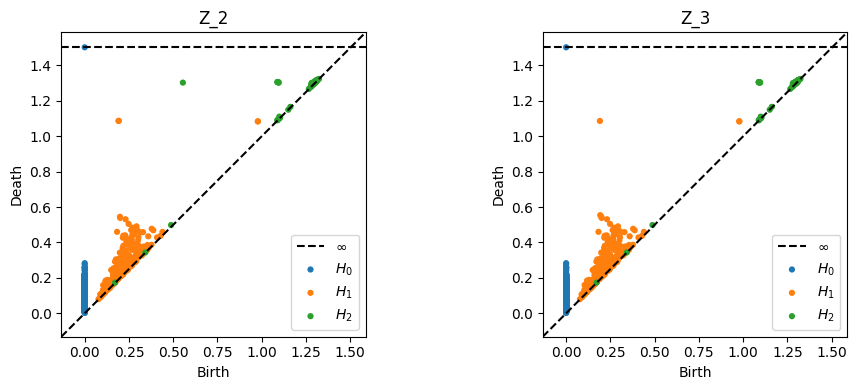

In [ ]:
diagrams2 = ripser(X, coeff=2, maxdim=2)['dgms']
diagrams3 = ripser(X, coeff=3, maxdim=2)['dgms']

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].set_title('Z_2')
plot_diagrams(diagrams2, ax=axes[0], show=False)

axes[1].set_title('Z_3')
plot_diagrams(diagrams3, ax=axes[1], show=False)

plt.tight_layout()
plt.show()

/Users/snopoff/Documents/Research/KleinVAE/.venv/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/snopoff/Documents/Research/KleinVAE/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/snopoff/Documents/Research/KleinVAE/.venv/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


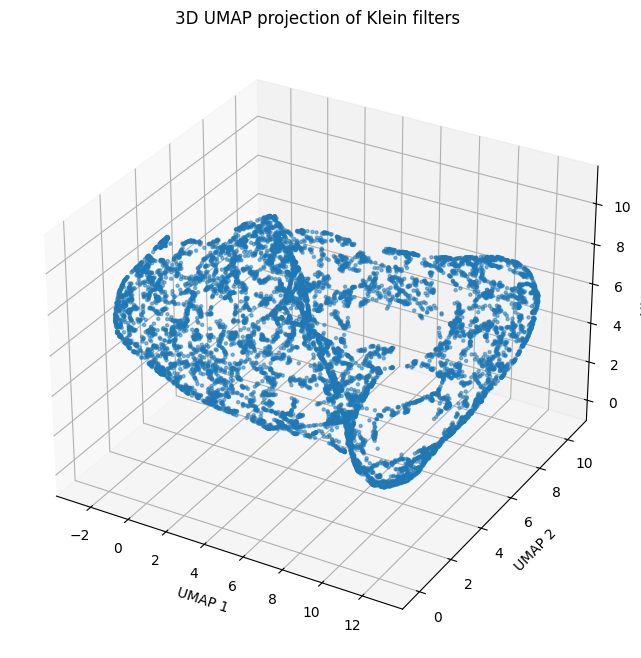

In [13]:
reducer = umap.UMAP(n_components=3, random_state=42)
reducer.fit(X)
embedding = reducer.transform(X)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(embedding[:, 0], embedding[:, 1], embedding[:, 2], s=5, alpha=0.5)
ax.set_title('3D UMAP projection of Klein filters')
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_zlabel('UMAP 3')
plt.show()

### $\theta_1$ runs up to $2\pi$
So we should get the homology of the 2-dimensional torus - it is almost the same:
$$
H_i(T^2;\Z) = 
\begin{cases}
\Z, \text{ if } i=0,2 \\
\Z^2, \text{ if } i=1 \\
0, \text{ otherwise.}
\end{cases}
$$

In [13]:
n_angles = 1_000

th1s = np.random.uniform(0, 2 * np.pi, n_angles)
th2s = np.random.uniform(0, 2 * np.pi, n_angles)

In [14]:
filters = [None]*n_angles

for i, thetas in enumerate(zip(th1s, th2s)):
    theta_1, theta_2 = thetas
    klein_filter_matrix = generate_klein_filter_matrix(theta_1, theta_2, size=3)
    filters[i] = klein_filter_matrix.flatten()
    
X = np.array(filters)
X.shape

(1000, 9)

/Users/snopoff/Documents/Research/KleinVAE/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/snopoff/Documents/Research/KleinVAE/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/snopoff/Documents/Research/KleinVAE/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


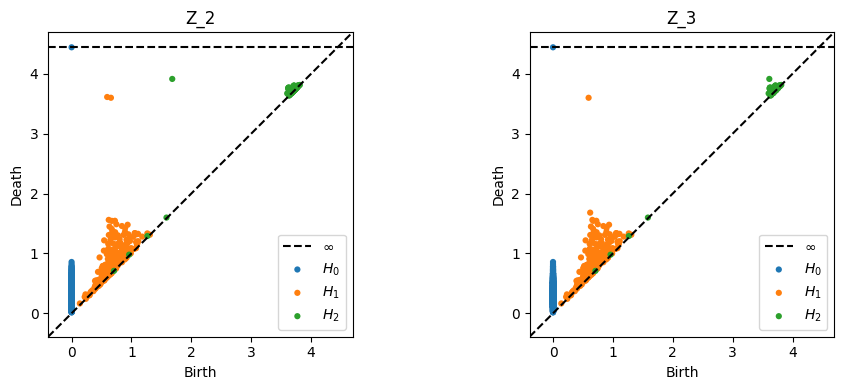

In [15]:
diagrams2 = ripser(X, coeff=2, maxdim=2)['dgms']
diagrams3 = ripser(X, coeff=3, maxdim=2)['dgms']

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].set_title('Z_2')
plot_diagrams(diagrams2, ax=axes[0], show=False)

axes[1].set_title('Z_3')
plot_diagrams(diagrams3, ax=axes[1], show=False)

plt.tight_layout()
plt.show()